# TP N°4 : Les Réseaux de Neurones Récurrents


---

**Objectif :** Comparer trois architectures (Dense, CNN, LSTM) pour la classification de sentiment sur le dataset IMDB.

## 1. Importation des bibliothèques

In [3]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

nltk.download('stopwords')
from nltk.corpus import stopwords

from numpy import array, asarray, zeros

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Activation, Dropout, Dense,
    Flatten, Conv1D, GlobalMaxPooling1D,
    LSTM, GRU, Embedding, MaxPooling1D
)

from sklearn.model_selection import train_test_split



[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


---
## 2. Importation et exploration du dataset



In [4]:
IMDB_PATH = "IMDB Dataset.csv"
GLOVE_PATH = "glove.6B.100d.txt"

movie_reviews = pd.read_csv(IMDB_PATH)

print("Dimensions du dataset :", movie_reviews.shape)
print("\nValeurs NULL :")
print(movie_reviews.isnull().sum())
print()
movie_reviews.head()

Dimensions du dataset : (50000, 2)

Valeurs NULL :
review       0
sentiment    0
dtype: int64



,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


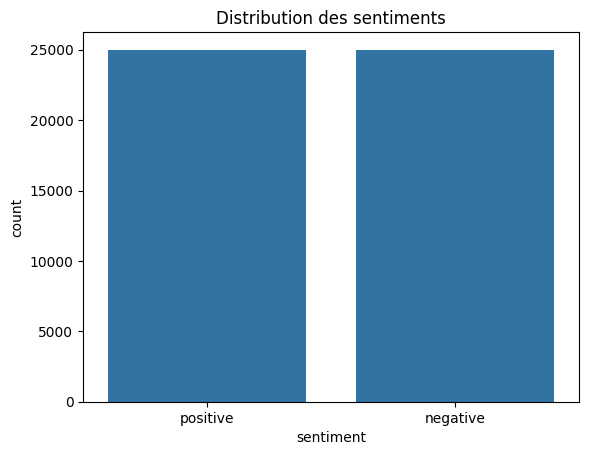

In [5]:
# Distribution des classes
sns.countplot(x='sentiment', data=movie_reviews)
plt.title('Distribution des sentiments')
plt.show()

In [6]:
# Afficher le 4ème review
print("=== 4ème review (brut) ===")
print(movie_reviews['review'][3])

=== 4ème review (brut) ===
Basically there's a family where a little boy (Jake) thinks there's a zombie in his closet & his parents are fighting all the time.<br /><br />This movie is slower than a soap opera... and suddenly, Jake decides to become Rambo and kill the zombie.<br /><br />OK, first of all when you're going to make a film you must Decide if its a thriller or a drama! As a drama the movie is watchable. Parents are divorcing & arguing like in real life. And then we have Jake with his closet which totally ruins all the film! I expected to see a BOOGEYMAN similar movie, and instead i watched a drama with some meaningless thriller spots.<br /><br />3 out of 10 just for the well playing parents & descent dialogs. As for the shots with Jake: just ignore them.


Dataset de 50,000 reviews, il existe aucune valeur NULL. le dataset est Parfaitement équilibré (25,000 positif, 25,000 négatif). Le 4ème review contient  des balises HTML  qui devront être nettoyées avant l'entraînement.


---
## 3. Prétraitement des données

In [7]:
# ── Fonction de nettoyage des balises HTML ──────────────────────
TAG_RE = re.compile(r'<[^>]+>')

def remove_tags(text):
    return TAG_RE.sub('', text)


def preprocess_text(sen):
    sentence = remove_tags(sen)                          # Suppression des balises HTML
    sentence = re.sub('[^a-zA-Z]', ' ', sentence)        # Suppression des ponctuations et chiffres
    sentence = re.sub(r"\s+[a-zA-Z]\s+", ' ', sentence) # Suppression des caractères isolés
    sentence = re.sub(r'\s+', ' ', sentence)             # Suppression des espaces multiples
    return sentence


# Appliquer le prétraitement
X = []
sentences = list(movie_reviews['review'])
for sen in sentences:
    X.append(preprocess_text(sen))

# Afficher le 4ème review aprés prétraitement
print(X[3])

Basically there a family where little boy Jake thinks there a zombie in his closet his parents are fighting all the time This movie is slower than soap opera and suddenly Jake decides to become Rambo and kill the zombie OK first of all when you re going to make film you must Decide if its thriller or drama As drama the movie is watchable Parents are divorcing arguing like in real life And then we have Jake with his closet which totally ruins all the film expected to see BOOGEYMAN similar movie and instead watched drama with some meaningless thriller spots out of just for the well playing parents descent dialogs As for the shots with Jake just ignore them 


le review ne contient plus les balises html

In [8]:
# Encodage des étiquettes
y = movie_reviews['sentiment']
y = np.array(list(map(lambda x: 1 if x == "positive" else 0, y)))
print("Distribution des labels :", np.bincount(y))

Distribution des labels : [25000 25000]


In [9]:
# Split train / test (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)
print(f"Train : {len(X_train)} | Test : {len(X_test)}")

Train : 40000 | Test : 10000


---
## 4. Couche d'Embedding — Tokenisation et GloVe

In [10]:
# Tokenisation : construction du dictionnaire word-to-index
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

# Taille du vocabulaire
vocab_size = len(tokenizer.word_index) + 1  # +1 pour l'index  0
print(f"Taille du vocabulaire : {vocab_size}")

# Padding : toutes les séquences à la même longueur 100
maxlen = 100
X_train_pad = pad_sequences(X_train_seq, padding='post', maxlen=maxlen)
X_test_pad  = pad_sequences(X_test_seq,  padding='post', maxlen=maxlen)
print(f"Shape X_train_pad : {X_train_pad.shape}")
print(f"Shape X_test_pad  : {X_test_pad.shape}")

Taille du vocabulaire : 92547
Shape X_train_pad : (40000, 100)
Shape X_test_pad  : (10000, 100)


In [11]:
# Chargement des embeddings GloVe (100d)
embeddings_dictionary = dict()

with open(GLOVE_PATH, encoding='utf8') as glove_file:
    for line in glove_file:
        records = line.split()
        word = records[0]
        vector_dimensions = asarray(records[1:], dtype='float32')
        embeddings_dictionary[word] = vector_dimensions

print(f"Nombre de mots dans GloVe : {len(embeddings_dictionary)}")

# Construction de la matrice d'embeddings
embedding_matrix = zeros((vocab_size, 100))
for word, index in tokenizer.word_index.items():
    embedding_vector = embeddings_dictionary.get(word)
    if embedding_vector is not None:
        embedding_matrix[index] = embedding_vector

print(f"Shape embedding_matrix : {embedding_matrix.shape}")

Nombre de mots dans GloVe : 400000
Shape embedding_matrix : (92547, 100)


---
## A. Classification — Réseau Dense (simple)

Architecture : `Embedding → Flatten → Dense(1, sigmoid)`

In [12]:
def build_dense_model():
    model = Sequential([
        Embedding(vocab_size, 100,
                  weights=[embedding_matrix],
                  input_length=maxlen,
                  trainable=False),
        Flatten(),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['acc'])
    return model

model_dense = build_dense_model()
model_dense.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │     9,254,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,254,700 (35.30 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 9,254,700 (35.30 MB)

In [13]:
history_dense = model_dense.fit(
    X_train_pad, y_train,
    epochs=6,
    batch_size=128,
    verbose=1,
    validation_split=0.2
)

Epoch 1/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - acc: 0.6717 - loss: 0.6013 - val_acc: 0.7139 - val_loss: 0.5573
Epoch 2/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - acc: 0.7607 - loss: 0.4953 - val_acc: 0.7418 - val_loss: 0.5223
Epoch 3/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - acc: 0.7863 - loss: 0.4600 - val_acc: 0.7436 - val_loss: 0.5205
Epoch 4/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - acc: 0.8021 - loss: 0.4334 - val_acc: 0.7322 - val_loss: 0.5410
Epoch 5/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - acc: 0.8055 - loss: 0.4235 - val_acc: 0.7402 - val_loss: 0.5305
Epoch 6/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - acc: 0.8157 - loss: 0.4061 - val_acc: 0.7474 - val_loss: 0.5323


In [14]:
# Évaluation
score_dense = model_dense.evaluate(X_test_pad, y_test, verbose=1)
print("Test Score    :", score_dense[0])
print("Test Accuracy :", score_dense[1])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - acc: 0.7411 - loss: 0.5354
Test Score    : 0.535398542881012
Test Accuracy : 0.741100013256073


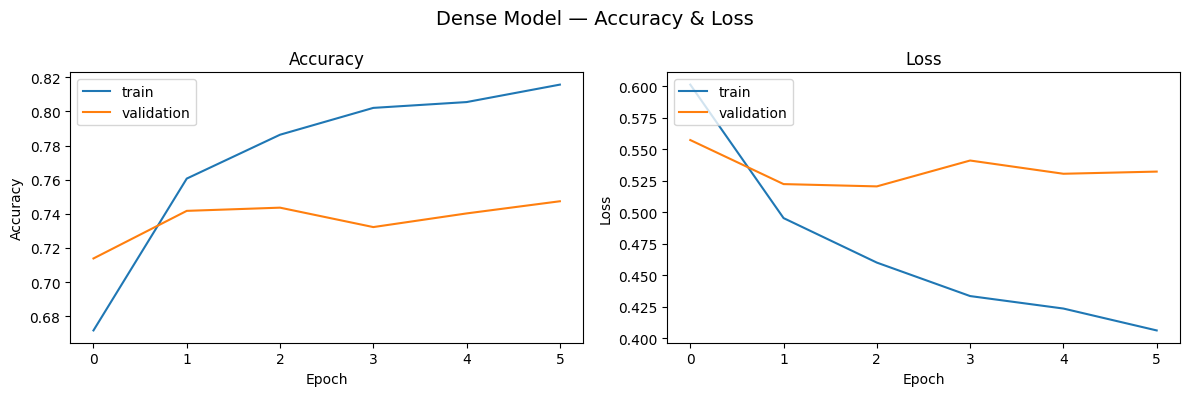

In [15]:
def plot_history(history, title=''):
    """Trace les courbes accuracy et loss (train vs validation)."""
    acc_key  = 'acc'      if 'acc'      in history.history else 'accuracy'
    vacc_key = 'val_acc'  if 'val_acc'  in history.history else 'val_accuracy'

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(title, fontsize=14)

    # Accuracy
    axes[0].plot(history.history[acc_key],  label='train')
    axes[0].plot(history.history[vacc_key], label='validation')
    axes[0].set_title('Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend(loc='upper left')

    # Loss
    axes[1].plot(history.history['loss'],     label='train')
    axes[1].plot(history.history['val_loss'], label='validation')
    axes[1].set_title('Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend(loc='upper left')

    plt.tight_layout()
    plt.show()

plot_history(history_dense, 'Dense Model — Accuracy & Loss')

# Observations:

La courbe d'accuracy d'entraînement augmente régulièrement (~81%) tandis que la validation stagne (~74%)
La loss d'entraînement diminue mais la validation loss augmente légèrement après l'époque 2-3


# Conclusion:
Le modèle Dense montre des signes d'overfitting ,  il apprend bien sur les données d'entraînement mais généralise mal sur la validation.

---
## B. Classification — Réseau CNN (Conv1D)

Architecture : `Embedding → Conv1D(128,5,relu) → GlobalMaxPooling1D → Dense(1, sigmoid)`

In [16]:
def build_cnn_model():
    model = Sequential([
        Embedding(vocab_size, 100,
                  weights=[embedding_matrix],
                  input_length=maxlen,
                  trainable=False),
        Conv1D(128, 5, activation='relu'),
        GlobalMaxPooling1D(),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['acc'])
    return model

model_cnn = build_cnn_model()
model_cnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │     9,254,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,254,700 (35.30 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 9,254,700 (35.30 MB)

In [17]:
history_cnn = model_cnn.fit(
    X_train_pad, y_train,
    epochs=6,
    batch_size=128,
    verbose=1,
    validation_split=0.2
)

Epoch 1/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - acc: 0.7537 - loss: 0.4993 - val_acc: 0.8219 - val_loss: 0.3965
Epoch 2/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - acc: 0.8365 - loss: 0.3717 - val_acc: 0.8381 - val_loss: 0.3621
Epoch 3/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - acc: 0.8644 - loss: 0.3228 - val_acc: 0.8419 - val_loss: 0.3526
Epoch 4/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - acc: 0.8849 - loss: 0.2849 - val_acc: 0.8389 - val_loss: 0.3541
Epoch 5/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - acc: 0.9019 - loss: 0.2488 - val_acc: 0.8490 - val_loss: 0.3414
Epoch 6/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - acc: 0.9223 - loss: 0.2134 - val_acc: 0.8478 - val_loss: 0.3435


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - acc: 0.8514 - loss: 0.3387
Test Score    : 0.3386809527873993
Test Accuracy : 0.8514000177383423


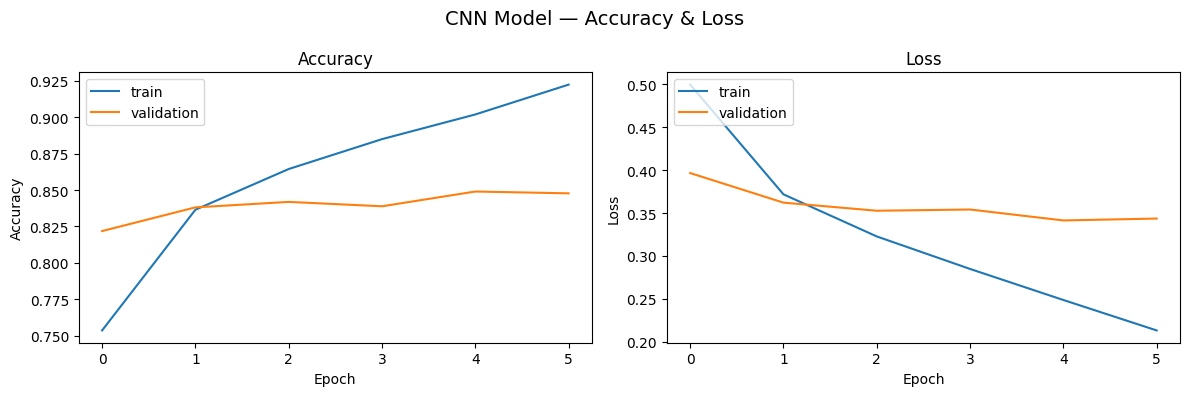

In [18]:
score_cnn = model_cnn.evaluate(X_test_pad, y_test, verbose=1)
print("Test Score    :", score_cnn[0])
print("Test Accuracy :", score_cnn[1])

plot_history(history_cnn, 'CNN Model — Accuracy & Loss')

---
## C. Classification — Réseau LSTM

Architecture : `Embedding → LSTM(128) → Dense(1, sigmoid)`

In [19]:
def build_lstm_model():
    model = Sequential([
        Embedding(vocab_size, 100,
                  weights=[embedding_matrix],
                  input_length=maxlen,
                  trainable=False),
        LSTM(128),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['acc'])
    return model

model_lstm = build_lstm_model()
model_lstm.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │     9,254,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,254,700 (35.30 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 9,254,700 (35.30 MB)

In [20]:
history_lstm = model_lstm.fit(
    X_train_pad, y_train,
    epochs=6,
    batch_size=128,
    verbose=1,
    validation_split=0.2
)

Epoch 1/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - acc: 0.7108 - loss: 0.5582 - val_acc: 0.7887 - val_loss: 0.4601
Epoch 2/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - acc: 0.7886 - loss: 0.4546 - val_acc: 0.7840 - val_loss: 0.4619
Epoch 3/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - acc: 0.8208 - loss: 0.3971 - val_acc: 0.8309 - val_loss: 0.3784
Epoch 4/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - acc: 0.8358 - loss: 0.3694 - val_acc: 0.8159 - val_loss: 0.3899
Epoch 5/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - acc: 0.8474 - loss: 0.3462 - val_acc: 0.8441 - val_loss: 0.3488
Epoch 6/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - acc: 0.8603 - loss: 0.3234 - val_acc: 0.8530 - val_loss: 0.3425


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - acc: 0.8486 - loss: 0.3425
Test Score    : 0.3425372242927551
Test Accuracy : 0.8485999703407288


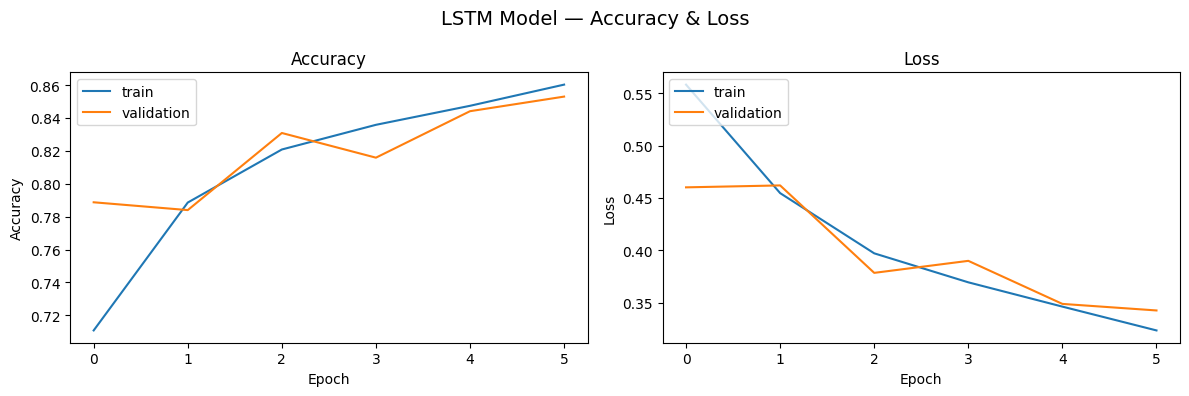

In [21]:
score_lstm = model_lstm.evaluate(X_test_pad, y_test, verbose=1)
print("Test Score    :", score_lstm[0])
print("Test Accuracy :", score_lstm[1])

plot_history(history_lstm, 'LSTM Model — Accuracy & Loss')

---
## C.4 — Comparaison des 3 classifieurs

Modèle  Test Loss  Test Acc
 Dense   0.535399    0.7411
   CNN   0.338681    0.8514
  LSTM   0.342537    0.8486


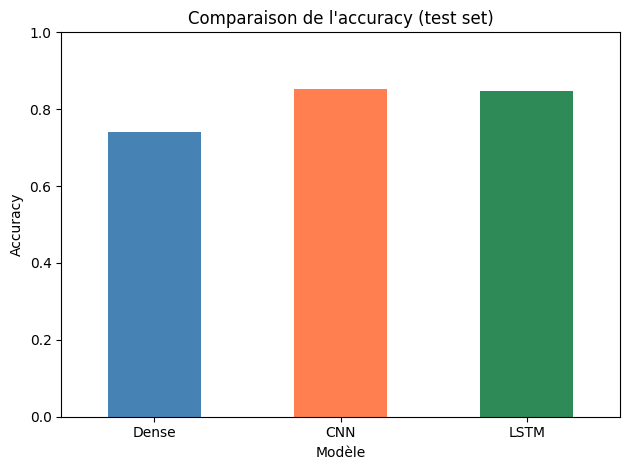

In [22]:
results = {
    'Modèle'   : ['Dense', 'CNN', 'LSTM'],
    'Test Loss': [score_dense[0], score_cnn[0], score_lstm[0]],
    'Test Acc' : [score_dense[1], score_cnn[1], score_lstm[1]]
}
df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

# Visualisation
df_results.plot(x='Modèle', y='Test Acc', kind='bar',
                color=['steelblue','coral','seagreen'],
                legend=False, ylim=(0, 1))
plt.title('Comparaison de l\'accuracy (test set)')
plt.ylabel('Accuracy')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

CNN et LSTM surpassent largement Dense (~84% vs 74%), grâce à leur capacité à capturer les motifs locaux (n-grammes pour CNN) et les dépendances séquentielles à long terme (LSTM). LSTM est légèrement meilleur que CNN, confirmant que la structure récurrente est plus adaptée au traitement du texte.

---
## C.5 — Prédire la polarité d'une instance aléatoire

In [23]:
import random

idx = random.randint(0, len(X_test) - 1)
sample_text = X_test[idx]
true_label  = y_test[idx]

# Préparation de l'instance
sample_seq = tokenizer.texts_to_sequences([sample_text])
sample_pad = pad_sequences(sample_seq, padding='post', maxlen=maxlen)

pred_dense = model_dense.predict(sample_pad)[0][0]
pred_cnn   = model_cnn.predict(sample_pad)[0][0]
pred_lstm  = model_lstm.predict(sample_pad)[0][0]

def label(p):
    return 'positive ' if p >= 0.5 else 'negative '

print(f"Review (extrait) : {sample_text[:200]}...")
print(f"Label réel       : {'positive' if true_label == 1 else 'negative'}")
print(f"Dense  → {label(pred_dense)} (score: {pred_dense:.4f})")
print(f"CNN    → {label(pred_cnn)}   (score: {pred_cnn:.4f})")
print(f"LSTM   → {label(pred_lstm)}  (score: {pred_lstm:.4f})")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
Review (extrait) : This show was an amazing fresh innovative idea in the when it first aired The first or years were brilliant but things dropped off after that By the show was not really funny anymore and it continued ...
Label réel       : negative
Dense  → negative  (score: 0.4371)
CNN    → negative    (score: 0.0648)
LSTM   → negative   (score: 0.0184)


# **Remarques :**

Le LSTM prédit correctement la polarité négative avec une très forte confiance (score: 0.0184 , 98% négatif), suivi du CNN (0.0648 ,93% négatif), tandis que le Dense est beaucoup moins confiant (0.4371 , 56% négatif).

Cela confirme que le LSTM capture le mieux le contexte global ("things dropped off after that", "not really funny anymore"), le CNN détecte aussi bien les motifs locaux négatifs, alors que le Dense, ignorant l'ordre des mots, reste hésitant.

---
##  Modèle GRU

Architecture : `Embedding → GRU(128) → Dense(1, sigmoid)`

In [24]:
def build_gru_model():
    model = Sequential([
        Embedding(vocab_size, 100,
                  weights=[embedding_matrix],
                  input_length=maxlen,
                  trainable=False),
        GRU(128),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['acc'])
    return model

model_gru = build_gru_model()
model_gru.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │     9,254,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,254,700 (35.30 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 9,254,700 (35.30 MB)

Epoch 1/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - acc: 0.7062 - loss: 0.5445 - val_acc: 0.8116 - val_loss: 0.4226
Epoch 2/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - acc: 0.8187 - loss: 0.3966 - val_acc: 0.8344 - val_loss: 0.3642
Epoch 3/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - acc: 0.8382 - loss: 0.3639 - val_acc: 0.8364 - val_loss: 0.3661
Epoch 4/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - acc: 0.8511 - loss: 0.3363 - val_acc: 0.8521 - val_loss: 0.3378
Epoch 5/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - acc: 0.8612 - loss: 0.3174 - val_acc: 0.8451 - val_loss: 0.3526
Epoch 6/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - acc: 0.8733 - loss: 0.2953 - val_acc: 0.8583 - val_loss: 0.3263
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - acc: 0.8583 - loss: 0.3206
Test Score    : 0.3205835521221161
Test Accuracy : 0.858299970626831


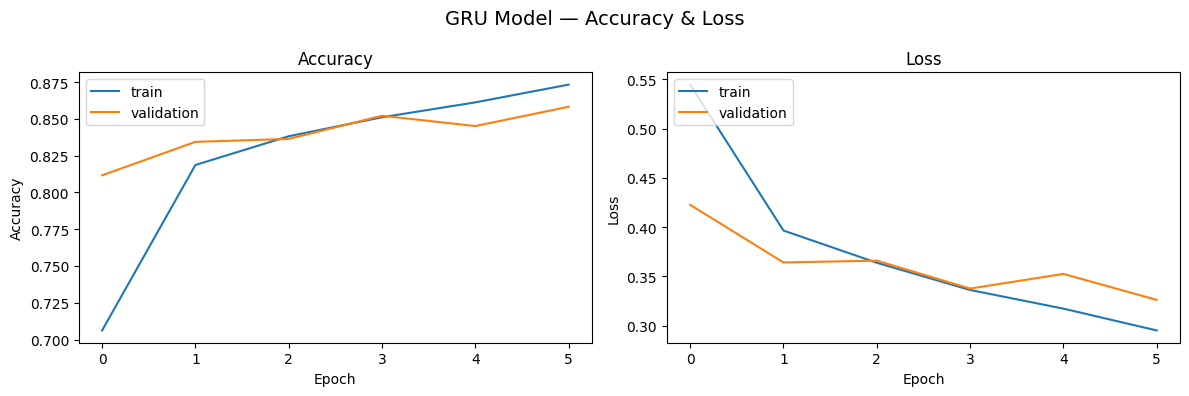

In [25]:
history_gru = model_gru.fit(
    X_train_pad, y_train,
    epochs=6,
    batch_size=128,
    verbose=1,
    validation_split=0.2
)

score_gru = model_gru.evaluate(X_test_pad, y_test, verbose=1)
print("Test Score    :", score_gru[0])
print("Test Accuracy :", score_gru[1])

plot_history(history_gru, 'GRU Model — Accuracy & Loss')

---
##  Modèle RNN + CNN hybride

In [26]:
from keras.layers import Bidirectional

def build_rnn_cnn_model():
    """
    Hybrid CNN + LSTM :
    Conv1D extrait les features locales, puis LSTM capture les dépendances séquentielles.
    """
    model = Sequential([
        Embedding(vocab_size, 100,
                  weights=[embedding_matrix],
                  input_length=maxlen,
                  trainable=False),
        Conv1D(64, 5, activation='relu'),
        MaxPooling1D(pool_size=2),
        LSTM(64),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['acc'])
    return model

model_rnn_cnn = build_rnn_cnn_model()
model_rnn_cnn.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │     9,254,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,254,700 (35.30 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 9,254,700 (35.30 MB)

Epoch 1/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - acc: 0.7058 - loss: 0.5560 - val_acc: 0.7436 - val_loss: 0.5213
Epoch 2/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - acc: 0.7930 - loss: 0.4410 - val_acc: 0.8234 - val_loss: 0.3982
Epoch 3/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - acc: 0.8261 - loss: 0.3862 - val_acc: 0.8397 - val_loss: 0.3666
Epoch 4/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - acc: 0.8419 - loss: 0.3569 - val_acc: 0.8365 - val_loss: 0.3777
Epoch 5/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - acc: 0.8509 - loss: 0.3393 - val_acc: 0.8376 - val_loss: 0.3581
Epoch 6/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - acc: 0.8641 - loss: 0.3154 - val_acc: 0.8397 - val_loss: 0.3591
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - acc: 0.8404 - loss: 0.3570
Test Score    : 0.3570200204849243
Test Accuracy : 0.840399980545044


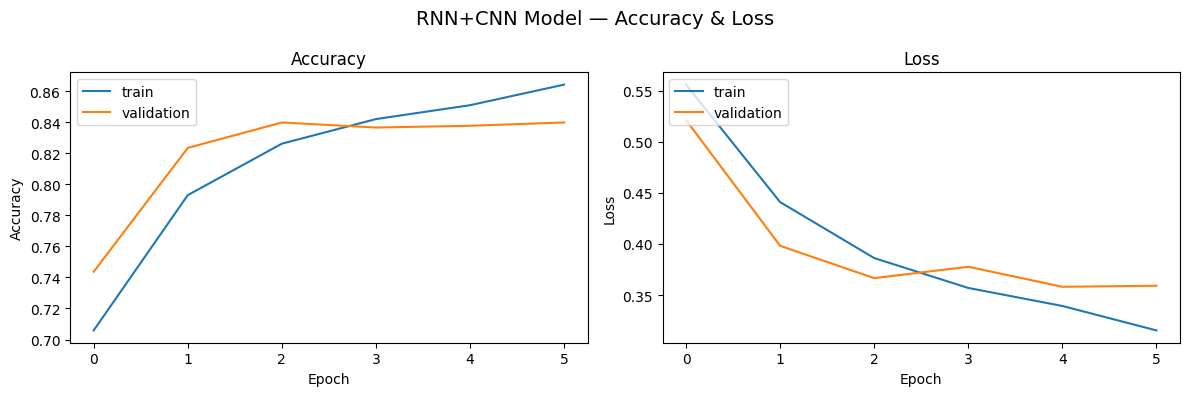

In [27]:
history_rnn_cnn = model_rnn_cnn.fit(
    X_train_pad, y_train,
    epochs=6,
    batch_size=128,
    verbose=1,
    validation_split=0.2
)

score_rnn_cnn = model_rnn_cnn.evaluate(X_test_pad, y_test, verbose=1)
print("Test Score    :", score_rnn_cnn[0])
print("Test Accuracy :", score_rnn_cnn[1])

plot_history(history_rnn_cnn, 'RNN+CNN Model — Accuracy & Loss')

In [28]:
#!pip install -q gensim

import gensim.downloader as api
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.layers import Embedding, LSTM, GRU, Dense, Conv1D, MaxPooling1D
from tensorflow.keras.models import Sequential
from sklearn.feature_extraction.text import TfidfVectorizer

In [29]:
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(X_train)
vocab_size = len(tokenizer.word_index) + 1
maxlen = 100
print(f"vocab_size: {vocab_size}, maxlen: {maxlen}")

vocab_size: 92547, maxlen: 100


In [30]:
print("Loading Word2Vec...")
w2v = api.load('word2vec-google-news-300')
print("Loading FastText...")
ft  = api.load('fasttext-wiki-news-subwords-300')

def make_matrix(model, dim):
    mat = np.zeros((vocab_size, dim))
    for word, idx in tokenizer.word_index.items():
        try:
            mat[idx] = model[word]
        except KeyError:
            pass
    return mat

emb_w2v = make_matrix(w2v, 300)
emb_ft  = make_matrix(ft, 300)
print("Embedding matrices created.")

Loading Word2Vec...
Loading FastText...
Embedding matrices created.


In [31]:
tfidf = TfidfVectorizer(max_features=5000)
X_train_tf = tfidf.fit_transform(X_train).toarray()
X_test_tf  = tfidf.transform(X_test).toarray()
print(f"TF-IDF shapes: {X_train_tf.shape}, {X_test_tf.shape}")

TF-IDF shapes: (40000, 5000), (10000, 5000)


In [32]:
def train_model(model, name, X_tr, y_tr, X_te, y_te, epochs=6, batch=128):
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['acc'])
    model.fit(X_tr, y_tr, epochs=epochs, batch_size=batch, verbose=1, validation_split=0.2)
    _, acc = model.evaluate(X_te, y_te, verbose=0)
    print(f"{name} Test Accuracy: {acc:.4f}\n")
    return acc

In [33]:
print("\n=== Word2Vec ===")

lstm_w2v = Sequential([
    Embedding(vocab_size, 300, weights=[emb_w2v], input_length=maxlen, trainable=False),
    LSTM(128),
    Dense(1, activation='sigmoid')
])
acc_lstm_w2v = train_model(lstm_w2v, "LSTM (Word2Vec)", X_train_pad, y_train, X_test_pad, y_test)

gru_w2v = Sequential([
    Embedding(vocab_size, 300, weights=[emb_w2v], input_length=maxlen, trainable=False),
    GRU(128),
    Dense(1, activation='sigmoid')
])
acc_gru_w2v = train_model(gru_w2v, "GRU (Word2Vec)", X_train_pad, y_train, X_test_pad, y_test)

hyb_w2v = Sequential([
    Embedding(vocab_size, 300, weights=[emb_w2v], input_length=maxlen, trainable=False),
    Conv1D(64, 5, activation='relu'),
    MaxPooling1D(2),
    LSTM(64),
    Dense(1, activation='sigmoid')
])
acc_hyb_w2v = train_model(hyb_w2v, "RNN+CNN (Word2Vec)", X_train_pad, y_train, X_test_pad, y_test)


=== Word2Vec ===
Epoch 1/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - acc: 0.7571 - loss: 0.4896 - val_acc: 0.8260 - val_loss: 0.3867
Epoch 2/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - acc: 0.8215 - loss: 0.3944 - val_acc: 0.8444 - val_loss: 0.3546
Epoch 3/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - acc: 0.8347 - loss: 0.3664 - val_acc: 0.8493 - val_loss: 0.3409
Epoch 4/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - acc: 0.8486 - loss: 0.3459 - val_acc: 0.8576 - val_loss: 0.3395
Epoch 5/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - acc: 0.8591 - loss: 0.3267 - val_acc: 0.8504 - val_loss: 0.3425
Epoch 6/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - acc: 0.8651 - loss: 0.3140 - val_acc: 0.8650 - val_loss: 0.3154
LSTM (Word2Vec) Test Accuracy: 0.8649

Epoch 1/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - acc: 0.7786 - loss: 0.4628 - val_acc: 0.8074 - val_loss: 0.4127
Epoch 2/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - acc: 0.8371 - loss: 0.3652 - val_acc: 0.8549 - val_loss: 0.3406

In [34]:
print("\n=== FastText ===")

lstm_ft = Sequential([
    Embedding(vocab_size, 300, weights=[emb_ft], input_length=maxlen, trainable=False),
    LSTM(128),
    Dense(1, activation='sigmoid')
])
acc_lstm_ft = train_model(lstm_ft, "LSTM (FastText)", X_train_pad, y_train, X_test_pad, y_test)

gru_ft = Sequential([
    Embedding(vocab_size, 300, weights=[emb_ft], input_length=maxlen, trainable=False),
    GRU(128),
    Dense(1, activation='sigmoid')
])
acc_gru_ft = train_model(gru_ft, "GRU (FastText)", X_train_pad, y_train, X_test_pad, y_test)

hyb_ft = Sequential([
    Embedding(vocab_size, 300, weights=[emb_ft], input_length=maxlen, trainable=False),
    Conv1D(64, 5, activation='relu'),
    MaxPooling1D(2),
    LSTM(64),
    Dense(1, activation='sigmoid')
])
acc_hyb_ft = train_model(hyb_ft, "RNN+CNN (FastText)", X_train_pad, y_train, X_test_pad, y_test)


=== FastText ===
Epoch 1/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - acc: 0.7326 - loss: 0.5312 - val_acc: 0.8033 - val_loss: 0.4648
Epoch 2/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - acc: 0.8062 - loss: 0.4285 - val_acc: 0.8229 - val_loss: 0.3960
Epoch 3/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - acc: 0.8160 - loss: 0.4055 - val_acc: 0.8285 - val_loss: 0.3861
Epoch 4/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - acc: 0.8250 - loss: 0.3898 - val_acc: 0.8342 - val_loss: 0.3775
Epoch 5/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - acc: 0.8370 - loss: 0.3689 - val_acc: 0.8354 - val_loss: 0.3906
Epoch 6/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - acc: 0.8390 - loss: 0.3626 - val_acc: 0.8160 - val_loss: 0.4112
LSTM (FastText) Test Accuracy: 0.8154

Epoch 1/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - acc: 0.7275 - loss: 0.5273 - val_acc: 0.8189 - val_loss: 0.4145
Epoch 2/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - acc: 0.8188 - loss: 0.3971 - val_acc: 0.8409 - val_loss: 0.3631

In [37]:
# Compute TF-IDF vectorizer on the training corpus
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(max_features=5000)
tfidf_vectorizer.fit(X_train)

# Get IDF values for each word in our tokenizer's vocabulary
word_to_idf = dict(zip(tfidf_vectorizer.get_feature_names_out(), tfidf_vectorizer.idf_))

# Create a scalar embedding matrix: shape (vocab_size, 1)
tfidf_embedding_matrix = np.zeros((vocab_size, 1))
for word, idx in tokenizer.word_index.items():
    if word in word_to_idf:
        tfidf_embedding_matrix[idx, 0] = word_to_idf[word]
    else:
        tfidf_embedding_matrix[idx, 0] = 0.0  # OOV words get 0


def train_tfidf_model(model, name):
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['acc'])
    model.fit(X_train_pad, y_train, epochs=6, batch_size=128, verbose=1, validation_split=0.2)
    _, acc = model.evaluate(X_test_pad, y_test, verbose=0)
    print(f"{name} TF-IDF Test Accuracy: {acc:.4f}\n")
    return acc

# LSTM with TF-IDF
lstm_tf = Sequential([
    Embedding(vocab_size, 1, weights=[tfidf_embedding_matrix], input_length=maxlen, trainable=False),
    LSTM(128),
    Dense(1, activation='sigmoid')
])
acc_lstm_tf = train_tfidf_model(lstm_tf, "LSTM")

# GRU with TF-IDF
gru_tf = Sequential([
    Embedding(vocab_size, 1, weights=[tfidf_embedding_matrix], input_length=maxlen, trainable=False),
    GRU(128),
    Dense(1, activation='sigmoid')
])
acc_gru_tf = train_tfidf_model(gru_tf, "GRU")

# RNN+CNN with TF-IDF
hyb_tf = Sequential([
    Embedding(vocab_size, 1, weights=[tfidf_embedding_matrix], input_length=maxlen, trainable=False),
    Conv1D(64, 5, activation='relu'),
    MaxPooling1D(2),
    LSTM(64),
    Dense(1, activation='sigmoid')
])
acc_hyb_tf = train_tfidf_model(hyb_tf, "RNN+CNN")

Epoch 1/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - acc: 0.5107 - loss: 0.6938 - val_acc: 0.5084 - val_loss: 0.6933
Epoch 2/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - acc: 0.5070 - loss: 0.6931 - val_acc: 0.5104 - val_loss: 0.6928
Epoch 3/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - acc: 0.5086 - loss: 0.6928 - val_acc: 0.5060 - val_loss: 0.6929
Epoch 4/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - acc: 0.5078 - loss: 0.6928 - val_acc: 0.5013 - val_loss: 0.6928
Epoch 5/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - acc: 0.5137 - loss: 0.6925 - val_acc: 0.5148 - val_loss: 0.6928
Epoch 6/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - acc: 0.5153 - loss: 0.6924 - val_acc: 0.5129 - val_loss: 0.6923
LSTM TF-IDF Test Accuracy: 0.5248

Epoch 1/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - acc: 0.5115 - loss: 0.6935 - val_acc: 0.5017 - val_loss: 0.6937
Epoch 2/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - acc: 0.5136 - loss: 0.6929 - val_acc: 0.5073 - val_loss: 0.6966
Epoch 3/6
250/250 ━━━━━━━━

In [38]:
print("\n" + "="*70)
print("| Classifieur | GloVe | Word2Vec | FastText |  TF-IDF  |")
print("|-------------|-------|----------|----------|----------|")
print(f"| LSTM        | {score_lstm[1]:.3f} | {acc_lstm_w2v:.3f}    | {acc_lstm_ft:.3f}    | {acc_lstm_tf:.3f}    |")
print(f"| GRU         | {score_gru[1]:.3f} | {acc_gru_w2v:.3f}    | {acc_gru_ft:.3f}    | {acc_gru_tf:.3f}    |")
print(f"| RNN+CNN     | {score_rnn_cnn[1]:.3f} | {acc_hyb_w2v:.3f}    | {acc_hyb_ft:.3f}    | {acc_hyb_tf:.3f}    |")
print("="*70)


| Classifieur | GloVe | Word2Vec | FastText |  TF-IDF  |
|-------------|-------|----------|----------|----------|
| LSTM        | 0.849 | 0.865    | 0.815    | 0.525    |
| GRU         | 0.858 | 0.862    | 0.852    | 0.519    |
| RNN+CNN     | 0.840 | 0.864    | 0.848    | 0.550    |


---
## interpretation et conclusion

- Choix des modèles :

LSTM / GRU : architectures récurrentes conçues pour capturer les dépendances à long terme dans les séquences textuelles
RNN+CNN : hybride combinant une extraction locale de motifs (Conv1D) et une modélisation séquentielle (LSTM), utile pour détecter des expressions clés tout en conservant le contexte global.



- Interprétation des résultats :

Word2Vec (≈86%) et GloVe (≈85%) dominent grâce à leurs représentations denses (300d/100d) qui encodent la similarité sémantique entre mots.
FastText (≈82-85%) performe légèrement moins bien car le corpus IMDB contient peu de mots rares où sa décomposition en sous‑mots excelle.
TF‑IDF (≈52-55%) échoue car chaque mot est réduit à un scalaire de fréquence, sans aucune information sur son sens ou ses relations avec d'autres termes.


- Conclusion :

La qualité de l'embedding est le facteur déterminant. Les modèles séquentiels (LSTM/GRU) nécessitent des représentations sémantiques denses pour fonctionner ; TF‑IDF, bien qu'efficace pour des classifieurs linéaires, ne convient pas ici.



